In [1]:
import pandas as pd
import re
from konlpy.tag import Okt
from mlxtend.preprocessing import TransactionEncoder 
import networkx as nx
import matplotlib.pyplot as plt
import koreanize_matplotlib
from wordcloud import WordCloud 
import matplotlib.pyplot as plt
import koreanize_matplotlib
from kiwipiepy import Kiwi

from PIL import Image 
import numpy as np 

okt = Okt()
kiwi = Kiwi()

In [4]:
df = pd.read_csv(
    "./data/Youtube_comment_01/raw/processed/youtube_comments_clean.csv",
    index_col = 0,
    keep_default_na=False
)
df.head()

,동영상 제목,채널명,댓글 유형,작성자,좋아요,작성일시,대댓글 수,댓글 ID,동영상 ID,작성자 채널 ID,수정일시,상위 댓글 ID,datetime,cleaned_comment
0,인간 아이돌(엔시티) VS 버츄얼아이돌(플레이브)#엔시티#플레이브#엔시티127,케이팝 읽어주는 남녀,최상위 댓글,@suroogarlieara,19837,2025-04-28T16:51:31Z,34,UgyEnpeXdwIa5NSRi714AaABAg,qOB5sIujPH8,UC_wT1ZdL5eGssgiwf_cfnqA,2025-04-28T16:51:31Z,none,2025-04-28 16:51:31,얔 던지는것도 웃기려고 하는거엿겠지만 저건 받아치는쪽이 잘 받아준겈
1,인간 아이돌(엔시티) VS 버츄얼아이돌(플레이브)#엔시티#플레이브#엔시티127,케이팝 읽어주는 남녀,대댓글,@dddongni,458,2025-04-29T10:53:51Z,0,UgyEnpeXdwIa5NSRi714AaABAg.AHTM32k7weKAHVHvITEHoU,qOB5sIujPH8,UCUiy_juTyQxcsDCUBUqwtNQ,2025-04-29T10:53:51Z,UgyEnpeXdwIa5NSRi714AaABAg,2025-04-29 10:53:51,저 트윗쓴사람 플레이브팬아님 조롱할려고 쓴 글임
2,인간 아이돌(엔시티) VS 버츄얼아이돌(플레이브)#엔시티#플레이브#엔시티127,케이팝 읽어주는 남녀,대댓글,@서현-l5d9m,117,2025-04-29T11:35:24Z,0,UgyEnpeXdwIa5NSRi714AaABAg.AHTM32k7weKAHVMffXbAVP,qOB5sIujPH8,UCA8NjllW2H9PoUDa0b5NYuA,2025-04-29T11:35:39Z,UgyEnpeXdwIa5NSRi714AaABAg,2025-04-29 11:35:24,헐 솔직히 전 플레이브 응원해요 힘내세요 다들 플레이브한테 욕많이 하시던데 팬분들 한테도
3,인간 아이돌(엔시티) VS 버츄얼아이돌(플레이브)#엔시티#플레이브#엔시티127,케이팝 읽어주는 남녀,대댓글,@이쥬-j1b,406,2025-04-29T13:41:15Z,0,UgyEnpeXdwIa5NSRi714AaABAg.AHTM32k7weKAHVa4Pzt_bL,qOB5sIujPH8,UCvXnUGHnZB61v1RGm_ox1zg,2025-04-29T13:41:15Z,UgyEnpeXdwIa5NSRi714AaABAg,2025-04-29 13:41:15,서현 플레이브팬들이 타팬덤들 후려쳐서 케이팝 팬덤들 공공의 적이 되어버림 업보여서 ...
4,인간 아이돌(엔시티) VS 버츄얼아이돌(플레이브)#엔시티#플레이브#엔시티127,케이팝 읽어주는 남녀,대댓글,@조수현-f5x,14,2025-04-29T14:19:28Z,0,UgyEnpeXdwIa5NSRi714AaABAg.AHTM32k7weKAHVeSLSNGS1,qOB5sIujPH8,UCbcRkR8dH-tN_fdbgjjrSMw,2025-04-29T14:19:28Z,UgyEnpeXdwIa5NSRi714AaABAg,2025-04-29 14:19:28,아니 버츄얼 아이돌이 왜 플레이브라는 듣보잡임 이세돌이나 스텔라이브가 근본인데 어디...


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4656 entries, 0 to 4655
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   동영상 제목           4656 non-null   str  
 1   채널명              4656 non-null   str  
 2   댓글 유형            4656 non-null   str  
 3   작성자              4656 non-null   str  
 4   좋아요              4656 non-null   int64
 5   작성일시             4656 non-null   str  
 6   대댓글 수            4656 non-null   int64
 7   댓글 ID            4656 non-null   str  
 8   동영상 ID           4656 non-null   str  
 9   작성자 채널 ID        4656 non-null   str  
 10  수정일시             4656 non-null   str  
 11  상위 댓글 ID         4656 non-null   str  
 12  datetime         4656 non-null   str  
 13  cleaned_comment  4656 non-null   str  
dtypes: int64(2), str(12)
memory usage: 509.4 KB


In [6]:
df["cleaned_comment"] = df["cleaned_comment"].fillna("")

In [7]:
# 반복문
word_list = []
stopwords = [
    "레이브", "힘빡쪼", "존나", "그렇다", "있다", "혹시", "그냥", "거가", 
    "오히려", "늬긔", "더라도", "힐거", "그게", "기네", "근끼", "정말",
    "끼리", "있넼존중", "저희", "진짜", "때문", "만큼", "어어", "나로",
    "뿌지직", "역시", "이번", "는걸", "쉐에에", "이다", "버츄얼", "아이돌",
    "버추얼", "한남", "허버허버", "스펀지밥", "네모", "드릉드릉", "오우",
    "깊은저", "스폰지밥", "깃치", "마을", "보성", "이세돌", "화이팅", "광대",
    "랄로", "공산주의", "버추"
]

# 패턴: [^0-9가-힣a-zA-Z\s]
for sent in df["cleaned_comment"]: # sent: 문장

    clean_sent = re.sub(r"[^가-힣a-zA-Z\s]", "", sent)
    result = okt.pos(clean_sent, norm=True, stem=True)
    sub_list = []

    for res in result: # res : (단어, 품사)
        word = res[0]
        pos = res[1]    

        if word in stopwords:
            continue

        if pos in ["Noun", "Adjective"] and len(word) > 1:
            sub_list.append(word)

    word_list.extend(sub_list)

In [8]:
print(len(word_list))

25836


In [9]:
for x in word_list:
    print(x)
    print("="*30)

저건
받아준겈
트윗
사람
아니다
조롱
글임
솔직하다
응원
서현
팬덤
케이팝
팬덤
공공
업보
없다
아니다
플레이
브라
듣보잡
스텔라
이브
근본
근본
알고리즘
자기
재밌다
같다
기절
타팬
조롱
글임
재밌다
아니다
조롱
정병
어그
인스타
이렇다
댓글
사운드
모음
철컹
차단
기키
소리
콘센트
꼽는
소리
컴퓨터
데이터
소리
시발
매니저
실수
데이
삭제
소리
위이잉키
소리
씹덕
응원
소리
공연
오빠
배터리
소리
철거
차단기
공연
소리
조롱
재밌다
얼굴
대체
노래
심지어
멋있다
부자연스럽다
기술
광야
어떻다
오빠
순간이동
도도
어떻다
언냐
로켓
펀처임
누구
해커
저기
엑소
광야
자만
이름
쎄다
돌이
슈퍼맨
여럿
스파이
사랑
카리나
로켓
펀쳐
윈터
지젤
제노글로시
닝닝
해커
에스
하늘
기본
발사
진심
하늘
기본
와이어
전문
물든
순간
민정
최고다
어인
벌레
야채
인간
말씀
나이비스
좋아하다
자기
좋아하다
사람
응원
서로
예의
날수
없다
좋아하다
자기
얼굴
다리
숭숭
아저씨
버츄
좋아하다
한가지
차라리
예쁘다
잘생기다
사람
우상화
좋아하다
나으니
낫다
외모
상주
매력
성공하다
다리
숭숭
아저씨
여자
보장
서로
죤내
어색하다
실제
시간
리노
좋아하다
정상
우리
학교
좋아하다
뭔가
결함
사람
애초
조롱
타팬
지고
불쌍하다
조롱
타팬
플리
모두
애기
사쿠라
프사
아니다
타팬
결말
한잔
꼬투리
팬덤
이미지
재밌다
버튜버
재밌다
가면라이더
나쁘다
같다
가면라이더
좋아하다
굳이
가세
버츄
오빠
가능하다
아니다
두꺼비
펜타킬
두꺼비
아뵹키
방송
정도
아니다
전장
지배
다르다
누가
아니다
팬덤
같다
결과
애초
팔정도
멘탈
아니다
기본
돌판
태도
기본
정도
무시
광야
오빠
공중부양
본기
같다
푸훗
좋아하다
서로
존중
덕질
본인
좋다
된거
어떻다
아닠
서로
오빠
비행
실력
가지
엔시
지네
식객
민우
여친
타팬
칭찬
이해
존경
플리
많다
수구
소수
민폐
하니
일반
화가
같다
식객
민우
여친
아니다
이미지
악의
댓글
안티
시간
리도
많다
댓글
무시
실제
사람
굉장하다
많다
플리
모두
존중
분위
기

# 2. 워드 클라우드

In [10]:
from collections import Counter 

counter = Counter(word_list)

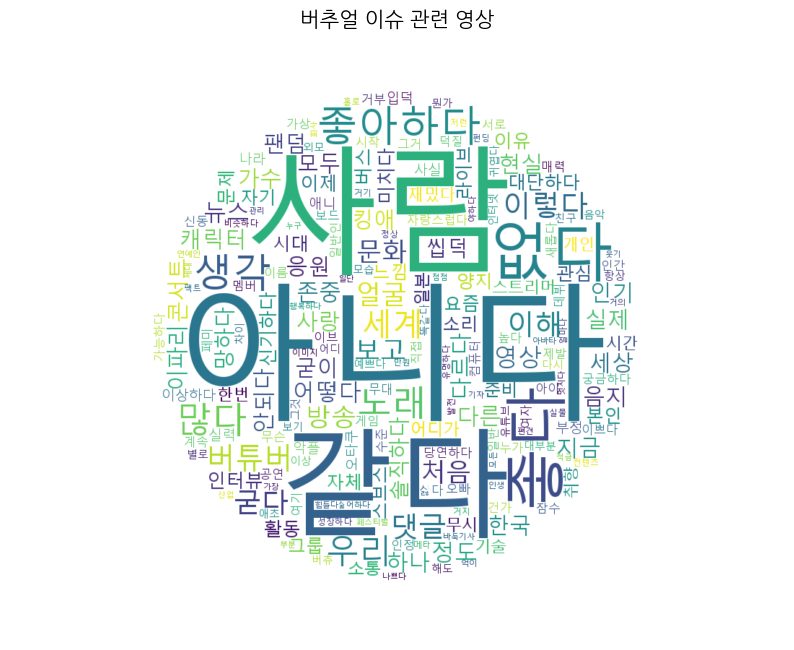

In [11]:
from wordcloud import WordCloud 
import matplotlib.pyplot as plt
import koreanize_matplotlib

from PIL import Image 
import numpy as np 

image = Image.open("C:/Users/user/Pictures/circle.png") # ./images/heart.png
mask_img = np.array(image)

wc = WordCloud(
    font_path = "C:\Windows\Fonts\malgun.ttf", # "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    background_color="white",
    mask=mask_img,
    width=800,
    height=400
)

wc.generate_from_frequencies(counter)

plt.figure(figsize=(10,10))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("버추얼 이슈 관련 영상", fontsize=15)
plt.show()

# 3. 장바구니 분석

In [12]:
# 반복문
word_list_2 = []
stopwords = [
    "레이브", "힘빡쪼", "존나", "그렇다", "있다", "혹시", "그냥", "거가", 
    "오히려", "늬긔", "더라도", "힐거", "그게", "기네", "근끼", "정말",
    "끼리", "있넼존중", "저희", "진짜", "때문", "만큼", "어어", "나로",
    "뿌지직", "역시", "이번", "는걸", "쉐에에", "이다", "버츄얼", "아이돌",
    "버추얼", "한남", "허버허버", "스펀지밥", "네모", "드릉드릉", "오우",
    "깊은저", "스폰지밥", "깃치", "마을", "보성", "이세돌", "화이팅", "광대", "랄로",
    "잠수", "준비"
]

# 패턴: [^0-9가-힣a-zA-Z\s]
for sent in df["cleaned_comment"]: # sent: 문장

    clean_sent = re.sub(r"[^가-힣a-zA-Z\s]", "", sent)
    result = okt.pos(clean_sent, norm=True, stem=True)
    sub_list = []

    for res in result: # res : (단어, 품사)
        word = res[0]
        pos = res[1]    

        if word in stopwords:
            continue

        if pos in ["Noun", "Adjective"] and len(word) > 1:
            sub_list.append(word)

    word_list_2.append(sub_list)

In [13]:
te = TransactionEncoder()
te_arr = te.fit(word_list_2).transform(word_list_2)
te_arr

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(4656, 4981))

In [14]:
df2 = pd.DataFrame(te_arr, columns=te.columns_)
df2

,가게,가격,가공,가까이,가깝다,가끔,가나,가능,가능성,가능하다,...,희다,희망,희망이,희생,희한하다,히키코모리,힐링,힘드다,힘들다,힙합
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4651,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4652,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4653,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4654,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [15]:
# 단어별로 출현한 횟수
df2.sum()

가게        1
가격        4
가공        1
가까이       1
가깝다      12
         ..
히키코모리     2
힐링        1
힘드다      18
힘들다      26
힙합        4
Length: 4981, dtype: int64

In [16]:
from mlxtend.frequent_patterns import apriori, association_rules 

# support는 전체 문장 중에 itemset이 등장한 문장의 비율
# min_support : support가 min_support 이상인것만 보여주세요
# max_len : max_len개의 조합까지 보여주세요
frequent_itemsets = apriori(df2, min_support=0.002, use_colnames=True, max_len=2)
frequent_itemsets

,support,itemsets
0,0.002577,frozenset({가깝다})
1,0.006658,frozenset({가능하다})
2,0.003436,frozenset({가면})
3,0.006658,frozenset({가상})
4,0.013746,frozenset({가수})
...,...,...
967,0.002148,"frozenset({활동, 좋다})"
968,0.003007,"frozenset({좋아하다, 지금})"
969,0.003866,"frozenset({좋아하다, 처음})"
970,0.004081,"frozenset({좋아하다, 캐릭터})"


In [17]:
# metric이 min_threshold 이상인 것만 보여주세요.
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules[["antecedents", "consequents", "support", "confidence", "lift"]]

,antecedents,consequents,support,confidence,lift
0,frozenset({같다}),frozenset({가능하다}),0.002148,0.032787,4.924379
1,frozenset({가능하다}),frozenset({같다}),0.002148,0.322581,4.924379
2,frozenset({사람}),frozenset({가상}),0.002792,0.035714,5.364055
3,frozenset({가상}),frozenset({사람}),0.002792,0.419355,5.364055
4,frozenset({아니다}),frozenset({가상}),0.002363,0.022133,3.324203
...,...,...,...,...,...
1043,frozenset({처음}),frozenset({좋아하다}),0.003866,0.178218,3.471892
1044,frozenset({좋아하다}),frozenset({캐릭터}),0.004081,0.079498,5.070442
1045,frozenset({캐릭터}),frozenset({좋아하다}),0.004081,0.260274,5.070442
1046,frozenset({처음}),frozenset({지금}),0.002148,0.099010,6.065659


In [18]:
# pivot_table
pivot_data = rules.head(20).pivot_table(
    index="antecedents",        # 행
    columns="consequents",      # 열
    values="confidence",                  # 기준
    fill_value=0                    # 매칭되지 않는 것은 이걸로 채워라.
)
pivot_data

consequents,frozenset({가능하다}),frozenset({같다}),frozenset({가상}),frozenset({사람}),frozenset({아니다}),frozenset({인물}),frozenset({가수}),frozenset({노래}),frozenset({생각}),frozenset({없다})
antecedents,,,,,,,,,,
frozenset({같다}),0.032787,0.000000,0.000000,0.000000,0.000000,0.000000,0.042623,0.0000,0.000000,0.0000
frozenset({가능하다}),0.000000,0.322581,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.0000
frozenset({사람}),0.000000,0.000000,0.035714,0.000000,0.000000,0.000000,0.032967,0.0000,0.000000,0.0000
frozenset({가상}),0.000000,0.000000,0.000000,0.419355,0.354839,0.354839,0.000000,0.0000,0.000000,0.0000
frozenset({아니다}),0.000000,0.000000,0.022133,0.000000,0.000000,0.000000,0.032193,0.0000,0.000000,0.0000
frozenset({인물}),0.000000,0.000000,0.733333,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.0000
frozenset({가수}),0.000000,0.203125,0.000000,0.187500,0.250000,0.000000,0.000000,0.3125,0.203125,0.1875
frozenset({노래}),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.119048,0.0000,0.000000,0.0000
frozenset({생각}),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.058036,0.0000,0.000000,0.0000


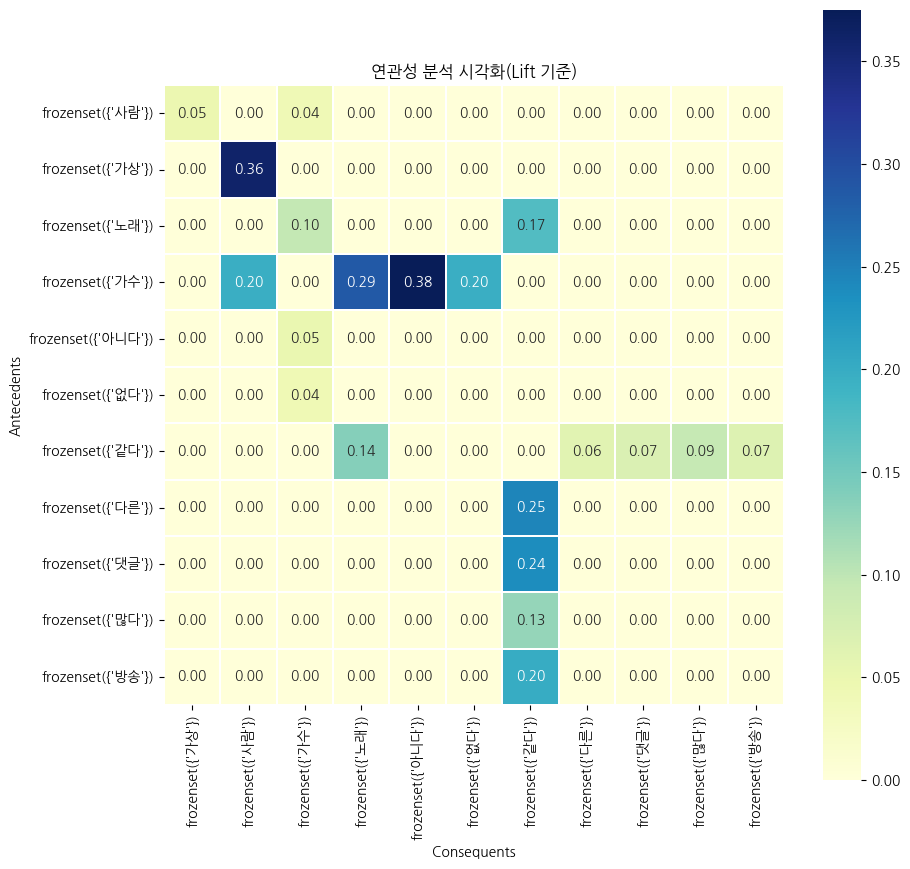

In [85]:
import matplotlib.pyplot as plt 
import seaborn as sns
import koreanize_matplotlib

plt.figure(figsize=(10,10))
sns.heatmap(pivot_data, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.3, square=True)
plt.title("연관성 분석 시각화(Lift 기준)")
plt.xlabel("Consequents")
plt.ylabel("Antecedents")
plt.show()

In [19]:
rules.head(2)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({같다}),frozenset({가능하다}),0.065507,0.006658,0.002148,0.032787,4.924379,1.0,0.001712,1.027015,0.852792,0.030675,0.026304,0.177684
1,frozenset({가능하다}),frozenset({같다}),0.006658,0.065507,0.002148,0.322581,4.924379,1.0,0.001712,1.379490,0.802270,0.030675,0.275094,0.177684


In [20]:
rules[["antecedents","consequents","support","confidence", "lift"]].head(2)

,antecedents,consequents,support,confidence,lift
0,frozenset({같다}),frozenset({가능하다}),0.002148,0.032787,4.924379
1,frozenset({가능하다}),frozenset({같다}),0.002148,0.322581,4.924379


In [21]:
sample_data = rules[["antecedents", "consequents"]].head(2)
for x in sample_data.iterrows():
    print(f"x의 요소 개수: {len(x)}")
    print(x[0])
    print("-"*50)
    print(x[1])
    print("="*50)

x의 요소 개수: 2
0
--------------------------------------------------
antecedents      frozenset({같다})
consequents    frozenset({가능하다})
Name: 0, dtype: object
x의 요소 개수: 2
1
--------------------------------------------------
antecedents    frozenset({가능하다})
consequents      frozenset({같다})
Name: 1, dtype: object


## 1) 지지도(Support)

In [22]:
## 보여주고 싶은 데이터 설정하기(여러분이 설정하세요.)
my_rules = rules.sort_values(by=["support"], ascending=False).head(100)

# 1. 그래프 생성
G = nx.Graph()

# 2. 엣지 추가
for _ , col_data in my_rules.iterrows():
    # 1) 단어 추출
    print(f"[BEFORE] {col_data['antecedents']}, {col_data['consequents']}")
    antecedent = ",".join(col_data["antecedents"])
    consequent = ",".join(col_data["consequents"])
    print(f"[AFTER] {antecedent}, {consequent}")
    print("="*100)

    # 2) 지표 추출
    weight = col_data["support"]

    # 3) 그래프에 정보 추가
    G.add_edge(antecedent, consequent, weight=weight)

[BEFORE] frozenset({'사람'}), frozenset({'아니다'})
[AFTER] 사람, 아니다
[BEFORE] frozenset({'아니다'}), frozenset({'사람'})
[AFTER] 아니다, 사람
[BEFORE] frozenset({'사람'}), frozenset({'좋아하다'})
[AFTER] 사람, 좋아하다
[BEFORE] frozenset({'좋아하다'}), frozenset({'사람'})
[AFTER] 좋아하다, 사람
[BEFORE] frozenset({'없다'}), frozenset({'사람'})
[AFTER] 없다, 사람
[BEFORE] frozenset({'사람'}), frozenset({'없다'})
[AFTER] 사람, 없다
[BEFORE] frozenset({'사람'}), frozenset({'생각'})
[AFTER] 사람, 생각
[BEFORE] frozenset({'생각'}), frozenset({'사람'})
[AFTER] 생각, 사람
[BEFORE] frozenset({'같다'}), frozenset({'아니다'})
[AFTER] 같다, 아니다
[BEFORE] frozenset({'아니다'}), frozenset({'같다'})
[AFTER] 아니다, 같다
[BEFORE] frozenset({'좋다'}), frozenset({'노래'})
[AFTER] 좋다, 노래
[BEFORE] frozenset({'노래'}), frozenset({'좋다'})
[AFTER] 노래, 좋다
[BEFORE] frozenset({'사람'}), frozenset({'같다'})
[AFTER] 사람, 같다
[BEFORE] frozenset({'같다'}), frozenset({'사람'})
[AFTER] 같다, 사람
[BEFORE] frozenset({'아니다'}), frozenset({'없다'})
[AFTER] 아니다, 없다
[BEFORE] frozenset({'없다'}), frozenset({'아니다'})
[AFTER] 없다, 아니다
[BEF

In [23]:
G.edges()

EdgeView([('사람', '아니다'), ('사람', '좋아하다'), ('사람', '없다'), ('사람', '생각'), ('사람', '같다'), ('사람', '많다'), ('사람', '좋다'), ('사람', '이렇다'), ('사람', '이해'), ('사람', '노래'), ('사람', '캐릭터'), ('사람', '보고'), ('사람', '실제'), ('아니다', '같다'), ('아니다', '없다'), ('아니다', '생각'), ('아니다', '좋아하다'), ('아니다', '좋다'), ('아니다', '많다'), ('아니다', '노래'), ('아니다', '이렇다'), ('아니다', '지금'), ('아니다', '버튜버'), ('좋아하다', '같다'), ('좋아하다', '좋다'), ('좋아하다', '생각'), ('좋아하다', '없다'), ('좋아하다', '많다'), ('좋아하다', '이해'), ('좋아하다', '노래'), ('없다', '생각'), ('없다', '같다'), ('없다', '좋다'), ('없다', '많다'), ('없다', '관심'), ('생각', '좋다'), ('생각', '같다'), ('생각', '많다'), ('생각', '문화'), ('생각', '노래'), ('생각', '이렇다'), ('같다', '좋다'), ('같다', '많다'), ('같다', '노래'), ('같다', '이해'), ('좋다', '노래'), ('좋다', '이렇다'), ('좋다', '세계'), ('좋다', '문화'), ('좋다', '많다')])

In [ ]:
G["아니다"]["사람"]

{'weight': 0.022336769759450172}

[0.6701030927835052, 0.5734536082474228, 0.5541237113402062, 0.509020618556701, 0.431701030927835, 0.38659793814432986, 0.37371134020618557, 0.21262886597938144, 0.21262886597938144, 0.20618556701030927, 0.1997422680412371, 0.18685567010309279, 0.17396907216494845, 0.47036082474226804, 0.431701030927835, 0.4252577319587629, 0.3801546391752577, 0.34149484536082475, 0.2577319587628866, 0.2448453608247423, 0.20618556701030927, 0.18041237113402062, 0.17396907216494845, 0.2963917525773196, 0.26417525773195877, 0.25128865979381443, 0.2448453608247423, 0.19329896907216493, 0.18685567010309279, 0.18041237113402062, 0.34149484536082475, 0.2706185567010309, 0.2384020618556701, 0.22551546391752578, 0.17396907216494845, 0.37371134020618557, 0.3157216494845361, 0.21262886597938144, 0.21262886597938144, 0.21262886597938144, 0.20618556701030927, 0.34149484536082475, 0.21262886597938144, 0.19329896907216493, 0.17396907216494845, 0.4381443298969072, 0.21262886597938144, 0.20618556701030927, 0.180412371

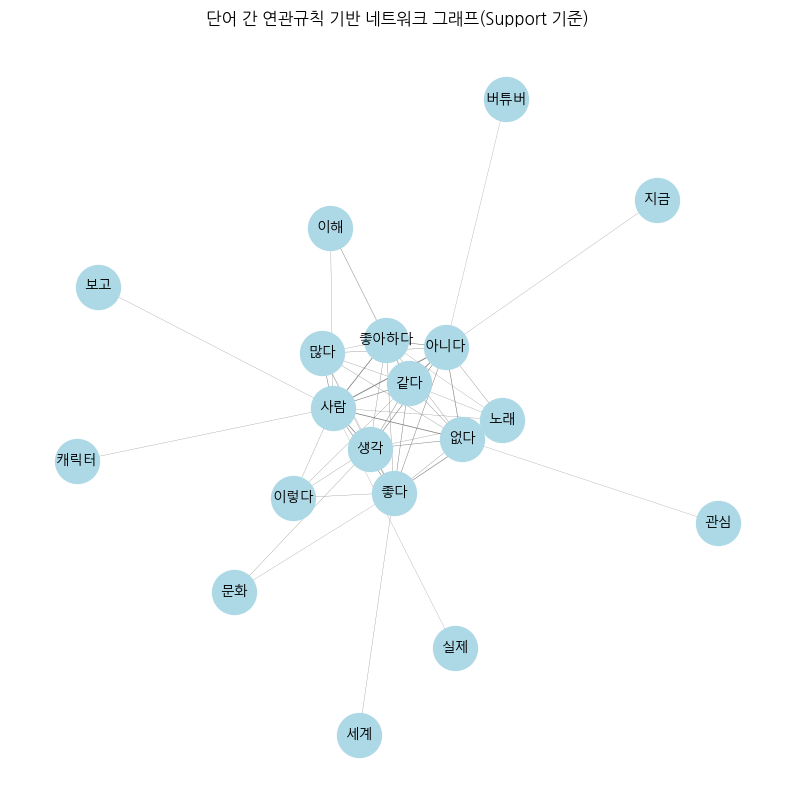

In [25]:
# 3. 노드 배치
# position = nx.kamada_kawai_layout(G, scale=0.5)
# k를 조절하면 노드간 거리를 조절할 수 있습니다.
position = nx.spring_layout(G, k=0.1, seed=50)

# 4. 가중치 추출
scale = 30.0 ## 선의 굵기가 너무 굵다면 사이즈를 줄일 수 있습니다.
edge_weights = [G[u][v]["weight"]*scale for u, v in G.edges()]
print(edge_weights)

# 5. 그리기
plt.figure(figsize=(10,10))
nx.draw_networkx_nodes(G, position, node_color="lightblue", node_size=1000)
nx.draw_networkx_edges(G, position, edge_color="gray", width=edge_weights)
nx.draw_networkx_labels(G, position, font_size=10, font_family="Malgun Gothic")
plt.title("단어 간 연관규칙 기반 네트워크 그래프(Support 기준)")
plt.axis("off")
plt.show()

## 2) 신뢰도(confidence)

In [26]:
## 보여주고 싶은 데이터 설정하기(여러분이 설정하세요.)
my_rules = rules.sort_values(by=["confidence"], ascending=False).head(100)

# 1. 그래프 생성
G = nx.Graph()

# 2. 엣지 추가
for _ , col_data in my_rules.iterrows():
    # 1) 단어 추출
    print(f"[BEFORE] {col_data['antecedents']}, {col_data['consequents']}")
    antecedent = ",".join(col_data["antecedents"])
    consequent = ",".join(col_data["consequents"])
    print(f"[AFTER] {antecedent}, {consequent}")
    print("="*100)

    # 2) 지표 추출
    weight = col_data["confidence"]

    # 3) 그래프에 정보 추가
    G.add_edge(antecedent, consequent, weight=weight)

[BEFORE] frozenset({'희망이'}), frozenset({'적금'})
[AFTER] 희망이, 적금
[BEFORE] frozenset({'엔카'}), frozenset({'이브'})
[AFTER] 엔카, 이브
[BEFORE] frozenset({'스텔라'}), frozenset({'이브'})
[AFTER] 스텔라, 이브
[BEFORE] frozenset({'메타'}), frozenset({'버스'})
[AFTER] 메타, 버스
[BEFORE] frozenset({'진입'}), frozenset({'장벽'})
[AFTER] 진입, 장벽
[BEFORE] frozenset({'장벽'}), frozenset({'진입'})
[AFTER] 장벽, 진입
[BEFORE] frozenset({'희망이'}), frozenset({'얼굴'})
[AFTER] 희망이, 얼굴
[BEFORE] frozenset({'희망이'}), frozenset({'무시'})
[AFTER] 희망이, 무시
[BEFORE] frozenset({'희망이'}), frozenset({'모두'})
[AFTER] 희망이, 모두
[BEFORE] frozenset({'희망이'}), frozenset({'깊다'})
[AFTER] 희망이, 깊다
[BEFORE] frozenset({'의미'}), frozenset({'없다'})
[AFTER] 의미, 없다
[BEFORE] frozenset({'수가'}), frozenset({'없다'})
[AFTER] 수가, 없다
[BEFORE] frozenset({'인물'}), frozenset({'가상'})
[AFTER] 인물, 가상
[BEFORE] frozenset({'깊다'}), frozenset({'무시'})
[AFTER] 깊다, 무시
[BEFORE] frozenset({'깊다'}), frozenset({'희망이'})
[AFTER] 깊다, 희망이
[BEFORE] frozenset({'깊다'}), frozenset({'얼굴'})
[AFTER] 깊다, 얼굴
[BEFORE] f

In [27]:
G.edges()

EdgeView([('희망이', '적금'), ('희망이', '얼굴'), ('희망이', '무시'), ('희망이', '모두'), ('희망이', '깊다'), ('적금', '깊다'), ('적금', '모두'), ('적금', '얼굴'), ('적금', '무시'), ('엔카', '이브'), ('이브', '스텔라'), ('메타', '버스'), ('진입', '장벽'), ('진입', '높다'), ('장벽', '높다'), ('얼굴', '깊다'), ('무시', '깊다'), ('의미', '없다'), ('없다', '수가'), ('없다', '관심'), ('없다', '대한'), ('없다', '문제'), ('없다', '차이'), ('없다', '부정'), ('없다', '거부'), ('없다', '발전'), ('없다', '애초'), ('인물', '가상'), ('가상', '사람'), ('홀로', '라이브'), ('입장', '생각'), ('생각', '수도'), ('생각', '비난'), ('생각', '개인'), ('생각', '문화'), ('생각', '인터넷'), ('애초', '아니다'), ('아니다', '대한'), ('아니다', '노력'), ('아니다', '비난'), ('아니다', '문제'), ('아니다', '당연하다'), ('아니다', '외모'), ('아니다', '부분'), ('아니다', '이상'), ('아니다', '방송인'), ('아니다', '느낌'), ('아니다', '싫다'), ('아니다', '취향'), ('아니다', '궁금하다'), ('아니다', '지금'), ('아니다', '악플'), ('아니다', '똑같다'), ('아니다', '수준'), ('아니다', '시간'), ('나라', '망하다'), ('누구', '사람'), ('사람', '당연하다'), ('사람', '거부'), ('사람', '캐릭터'), ('사람', '대부분'), ('사람', '외모'), ('사람', '본인'), ('사람', '매력'), ('사람', '서로'), ('사람', '좋아하다'), ('사람', '예쁘다'), ('사람', '소통'

In [28]:
G["사람"]["아니다"]

KeyError: '아니다'

[2020.1652892561983, 1940.0, 1790.7692307692307, 1293.333333333333, 1293.333333333333]


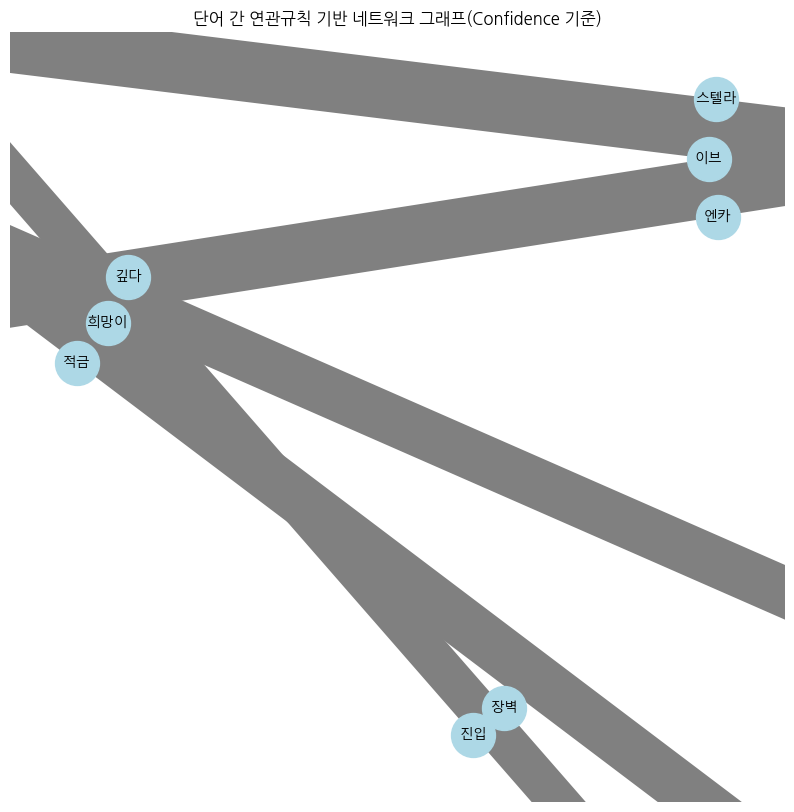

In [47]:
# 3. 노드 배치
# position = nx.kamada_kawai_layout(G, scale=0.5)
# k를 조절하면 노드간 거리를 조절할 수 있습니다.
position = nx.spring_layout(G, k=0.5, seed=200)

# 4. 가중치 추출
scale = 10.0 ## 선의 굵기가 너무 굵다면 사이즈를 줄일 수 있습니다.
edge_weights = [G[u][v]["weight"]*scale for u, v in G.edges()]
print(edge_weights)

# 5. 그리기
plt.figure(figsize=(10,10))
nx.draw_networkx_nodes(G, position, node_color="lightblue", node_size=1000)
nx.draw_networkx_edges(G, position, edge_color="gray", width=edge_weights)
nx.draw_networkx_labels(G, position, font_size=10, font_family="Malgun Gothic")
plt.title("단어 간 연관규칙 기반 네트워크 그래프(Confidence 기준)")
plt.axis("off")
plt.show()

## 3) 향상도(Lift)

In [48]:
## 보여주고 싶은 데이터 설정하기(여러분이 설정하세요.)
my_rules = rules.sort_values(by=["lift"], ascending=False).head(50)

# 1. 그래프 생성
G = nx.Graph()

# 2. 엣지 추가
for _ , col_data in my_rules.iterrows():
    # 1) 단어 추출
    print(f"[BEFORE] {col_data['antecedents']}, {col_data['consequents']}")
    antecedent = ",".join(col_data["antecedents"])
    consequent = ",".join(col_data["consequents"])
    print(f"[AFTER] {antecedent}, {consequent}")
    print("="*100)

    # 2) 지표 추출
    weight = col_data["lift"]

    # 3) 그래프에 정보 추가
    G.add_edge(antecedent, consequent, weight=weight)

[BEFORE] frozenset({'진입'}), frozenset({'장벽'})
[AFTER] 진입, 장벽
[BEFORE] frozenset({'장벽'}), frozenset({'진입'})
[AFTER] 장벽, 진입
[BEFORE] frozenset({'깊다'}), frozenset({'희망이'})
[AFTER] 깊다, 희망이
[BEFORE] frozenset({'희망이'}), frozenset({'깊다'})
[AFTER] 희망이, 깊다
[BEFORE] frozenset({'희망이'}), frozenset({'적금'})
[AFTER] 희망이, 적금
[BEFORE] frozenset({'적금'}), frozenset({'희망이'})
[AFTER] 적금, 희망이
[BEFORE] frozenset({'이브'}), frozenset({'스텔라'})
[AFTER] 이브, 스텔라
[BEFORE] frozenset({'스텔라'}), frozenset({'이브'})
[AFTER] 스텔라, 이브
[BEFORE] frozenset({'엔카'}), frozenset({'이브'})
[AFTER] 엔카, 이브
[BEFORE] frozenset({'이브'}), frozenset({'엔카'})
[AFTER] 이브, 엔카
[BEFORE] frozenset({'깊다'}), frozenset({'적금'})
[AFTER] 깊다, 적금
[BEFORE] frozenset({'적금'}), frozenset({'깊다'})
[AFTER] 적금, 깊다
[BEFORE] frozenset({'인물'}), frozenset({'가상'})
[AFTER] 인물, 가상
[BEFORE] frozenset({'가상'}), frozenset({'인물'})
[AFTER] 가상, 인물
[BEFORE] frozenset({'메타'}), frozenset({'버스'})
[AFTER] 메타, 버스
[BEFORE] frozenset({'버스'}), frozenset({'메타'})
[AFTER] 버스, 메타
[BEFORE] fro

In [49]:
G.edges()

EdgeView([('진입', '장벽'), ('진입', '높다'), ('장벽', '높다'), ('깊다', '희망이'), ('깊다', '적금'), ('깊다', '무시'), ('깊다', '얼굴'), ('희망이', '적금'), ('희망이', '무시'), ('희망이', '모두'), ('희망이', '얼굴'), ('적금', '무시'), ('적금', '모두'), ('이브', '스텔라'), ('이브', '엔카'), ('인물', '가상'), ('메타', '버스'), ('라이브', '홀로'), ('컴퓨터', '기자'), ('기술', '발전'), ('시대', '변하다'), ('망하다', '나라'), ('부정', '입덕'), ('본인', '직접'), ('존중', '취향')])

In [50]:
G["희망이"]["적금"]

{'weight': 179.07692307692307}

[202.01652892561984, 64.13223140495869, 70.54545454545455, 194.0, 119.38461538461537, 72.18604651162791, 34.48888888888889, 179.07692307692307, 81.20930232558139, 52.11940298507463, 38.8, 49.974955277280856, 45.437428243398394, 129.33333333333331, 129.33333333333331, 110.14193548387097, 108.27906976744185, 74.82857142857142, 60.07741935483872, 55.927927927927925, 49.53191489361702, 45.280338266384774, 42.969017798286096, 26.216216216216218, 24.22296544035675]


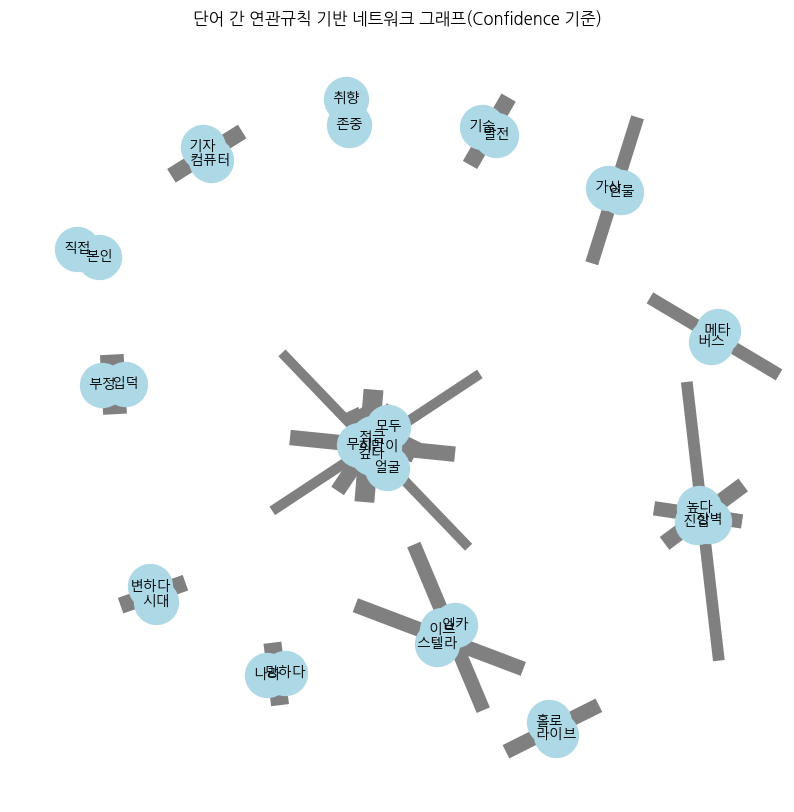

In [51]:
# 3. 노드 배치
# position = nx.kamada_kawai_layout(G, scale=0.5)
# k를 조절하면 노드간 거리를 조절할 수 있습니다.
position = nx.spring_layout(G, k=0.5, seed=400)

# 4. 가중치 추출
scale = 1.0 ## 선의 굵기가 너무 굵다면 사이즈를 줄일 수 있습니다.
edge_weights = [G[u][v]["weight"]*scale for u, v in G.edges()]
print(edge_weights)
    
# 5. 그리기
plt.figure(figsize=(10,10))
nx.draw_networkx_nodes(G, position, node_color="lightblue", node_size=1000)
nx.draw_networkx_edges(G, position, edge_color="gray", width=edge_weights)
nx.draw_networkx_labels(G, position, font_size=10, font_family="Malgun Gothic")
plt.title("단어 간 연관규칙 기반 네트워크 그래프(Confidence 기준)")
plt.axis("off")
plt.show()